<a href="https://colab.research.google.com/github/lee1201zxc/study/blob/main/AI/DL/09_3_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 기존 순환 신경망의 문제점 : 긴 시퀀스를 학습하기 어려움, 은닉 상태에 담긴 정보가 희석되서
# Gated RNN
gradient 안정적으로 유지하기 위해 사용

## LSTM(Long Short-Term Memory)
3가지 게이트로 구성

망각,입력,출력

은닉 상태 말고 "셀 상태"가 존재

셀 상태(C) -> 다음 층으로 전달되지 않고 현재 셀 안에서 순환되는, 기억을 오래 보존하는 통로

4개셀 존재


RNN은 곱셈구존데 LSTM은 덧셈구조여서 gradient가 직접 흐를 수 있음
<br><br>

입력 게이트 -> 은닉 상태 생성 = 이전 은닉 상태 가중치와 곱한 후 시그모이드(활성화 함수)에 통과시킴(0~1비율 조절을 위해)(RNN에선 tanh이였음)

삭제 게이트(F) -> 오래되거나 중요도 낮은거는 삭제해야해서

입력 게이트(I) -> 필요한 정보만 저장

출력 게이트(O) -> 필요한 정보만 노출

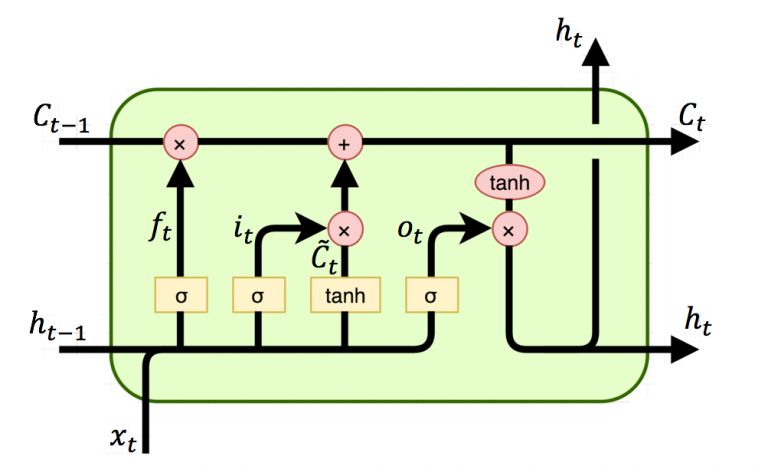



In [1]:
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

from keras.preprocessing.sequence import pad_sequences
# 길이 자르기
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
import keras

model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Input(shape=(100,)))
model_lstm.add(keras.layers.Embedding(500, 16))
# RNN대신 LSTM사용
# return_sequences -> 순환층에서 모든 타임스텝의 은닉 상태를 출력함. 원래는 마지막 타임스텝만 다음 층으로 전달했음
model_lstm.add(keras.layers.LSTM(8, dropout=0.2, return_sequences=True))
model_lstm.add(keras.layers.LSTM(8, dropout=0.2))
model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))

# LSTM 파라미터 SimpleRNN에 비해 4배됨(4개셀 있어서)
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights = True)
history = model_lstm.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 75ms/step - accuracy: 0.5943 - loss: 0.6538 - val_accuracy: 0.7664 - val_loss: 0.4982
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 85ms/step - accuracy: 0.7731 - loss: 0.4882 - val_accuracy: 0.7776 - val_loss: 0.4626
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.7913 - loss: 0.4559 - val_accuracy: 0.7968 - val_loss: 0.4388
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.8027 - loss: 0.4348 - val_accuracy: 0.7930 - val_loss: 0.4408
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step - accuracy: 0.8066 - loss: 0.4191 - val_accuracy: 0.8076 - val_loss: 0.4276
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.8125 - loss: 0.4114 - val_accuracy: 0.8004 - val_loss: 0.4282
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.8196 - loss: 0.3987 - val_accuracy: 0.7708 - val_loss: 0.4562
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.8156 - loss: 0

/tmp/ipython-input-1898665082.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


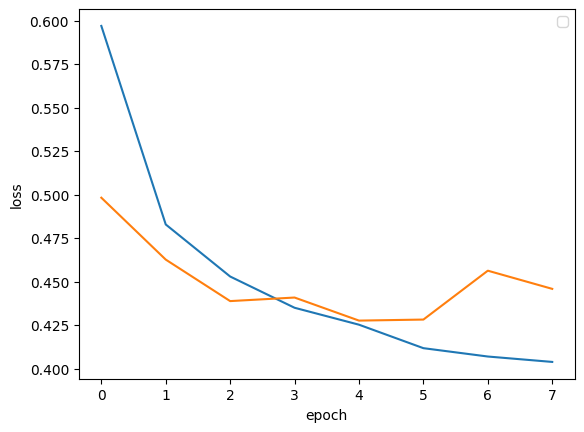

In [4]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()


## GRU(Gated Recurrent Unit)
LSTM 간소화 버전, 셀 상태 계산하지 않고 은닉 상태만 포함

게이트 2개, 3개셀# GRU(Gated Recurrent Unit)
LSTM 간소화 버전, 셀 상태 계산하지 않고 은닉 상태만 포함

게이트 2개, 3개셀

z -> update gate(과거 정보 얼마나 기억 유지할지)

r -> reset gate(과거 정보 얼마나 무시할지)

~h -> 후보 은닉 상태(reset gate반영해서 새로 계산된 새로운 기억 후보)

순서대로 삭제 게이트, 입력 정보 제어(wg)
wr은 은닉 상태 정보 제어


model_lstm.add(keras.layers.GRU(8, dropout=0.2))

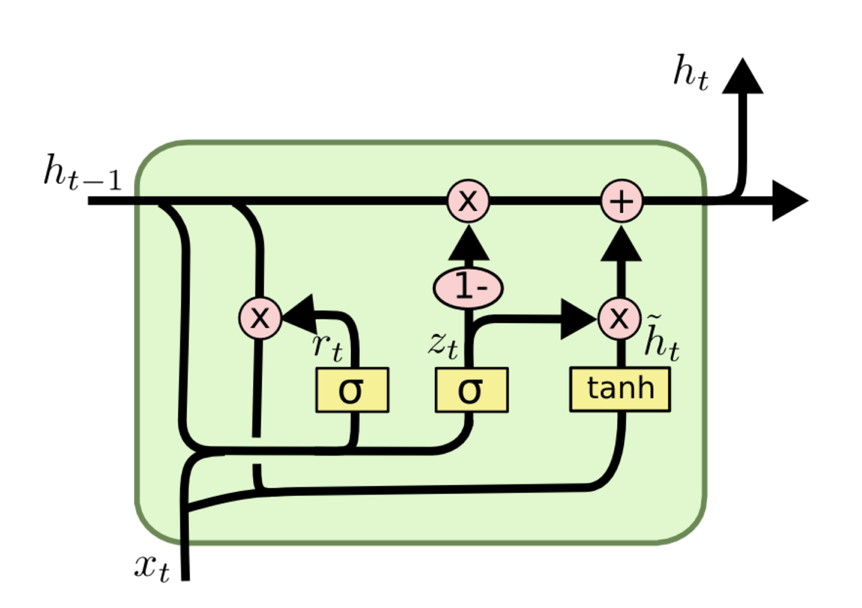
